# Exploratory analysis of microstructure and sampling clocks

**Asset:** SOLUSDT

**Goals:** 

- Characterize the statistical properties of the Limit Order Book (LOB) and trades to justify the design decisions of the predictive model. The presence of microstructure noise is evaluated, and heteroscedasticity is mitigated using volume clocks.

- Build a model that exploits the statistical properties discussed after defining a signal based on those properties.

For getting the data, we started recording when the NYSE during some days of late june 2026 and a some time before and after (from 9:10 to 10-11 approximately taking into account NY time). Even though the crypto market is always open, this time was set as a standard due to its high activity.

In [2]:
import pyarrow.dataset as ds
import pandas as pd
import matplotlib.pyplot as plt

# We will only load the first level (L1) for preventing memory saturation/overflow.
dataset_depth = ds.dataset("../../data/raw/depth/", format="parquet")
projection = ["event_time", "bid_p_1", "ask_p_1", "bid_q_1", "ask_q_1"]

df_depth = dataset_depth.to_table(columns=projection).to_pandas()

# Convert binance timestamp to standad UTC time
df_depth['datetime'] = pd.to_datetime(df_depth['event_time'], unit='ms', utc=True).dt.tz_convert('Europe/London')
df_depth.set_index('datetime', inplace=True)



print(f"LOB loaded successfully. Total rows: {len(df_depth)}")


# Now we wil load the trades
dataset_trades = ds.dataset("../../data/raw/trades", format="parquet")
df_trades = dataset_trades.to_table().to_pandas()

df_trades['datetime'] = pd.to_datetime(df_trades['event_time'], unit='ms', utc=True).dt.tz_convert('Europe/London')
df_trades.set_index('datetime', inplace=True)

df_trades['volume_usd'] = df_trades['price'] * df_trades['quantity']

print(f"Trades dataset loaded successfully. Number of trades: {len(df_trades)}")

LOB loaded successfully. Total rows: 99842
Trades dataset loaded successfully. Number of trades: 405642


We will start by analyzing how the bid-ask spread has changed over time:

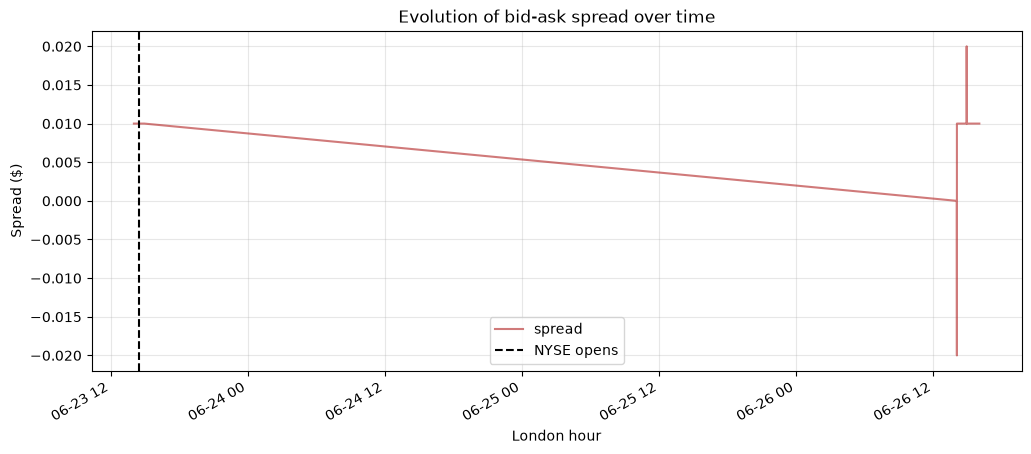

In [3]:
df_depth['mid_price'] = (df_depth['ask_p_1'] + df_depth['bid_p_1']) / 2
df_depth['spread'] = (df_depth['ask_p_1'] - df_depth['bid_p_1']).round(2)

plt.figure(figsize=(12, 5))
df_depth['spread'].plot(color='firebrick', alpha=0.6)
plt.axvline(pd.Timestamp('2026-06-23 14:30:00', tz='Europe/London'), color='black', linestyle='--', label='NYSE opens')
plt.title('Evolution of bid-ask spread over time')
plt.ylabel('Spread ($)')
plt.xlabel('London hour')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We observe that even after the NYSE open the spread is constant, it is always 0.01, this can be explained by the fact that SOLUSDT is considered a "large-tick" asset, making this market very efficient. This implies that it is constant all thoughout the day, since even in one of the most volatile moments (the NYSE opens) it maintained its value.

Since by looking at the spread we cannot obtain any relevant information, we will now look at the volume plotted over time.

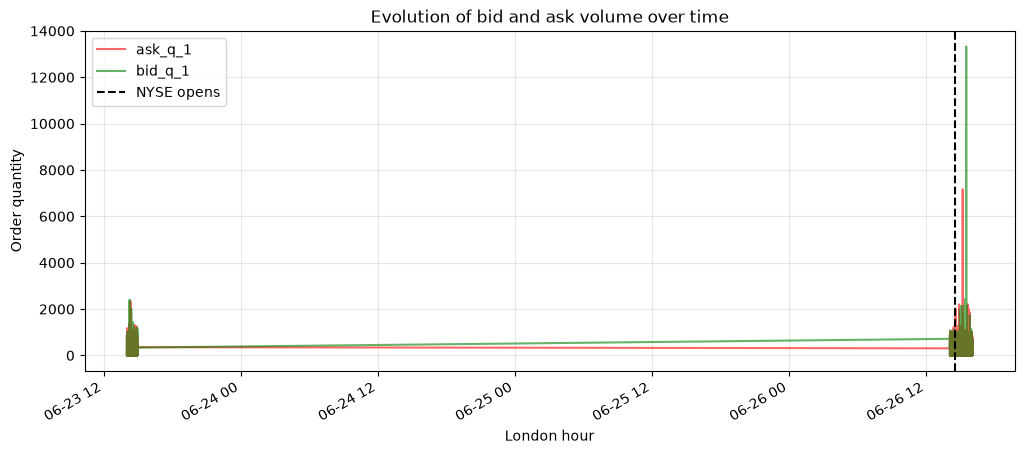

In [4]:
plt.figure(figsize=(12, 5))
df_depth['ask_q_1'].plot(color='red', alpha=0.6)
df_depth['bid_q_1'].plot(color='green', alpha=0.6)
plt.axvline(pd.Timestamp('14:30:00', tz='Europe/London'), color='black', linestyle='--', label='NYSE opens')
plt.title('Evolution of bid and ask volume over time')
plt.ylabel('Order quantity')
plt.xlabel('London hour')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Even though the data looks like just noise, it is interesting to note that after the NYSE has opened, the graph becomes a lot more dense, indicating a regime change.

We will now continue by, instead of plotting each point individually, grouping them in 1 minute intervals.

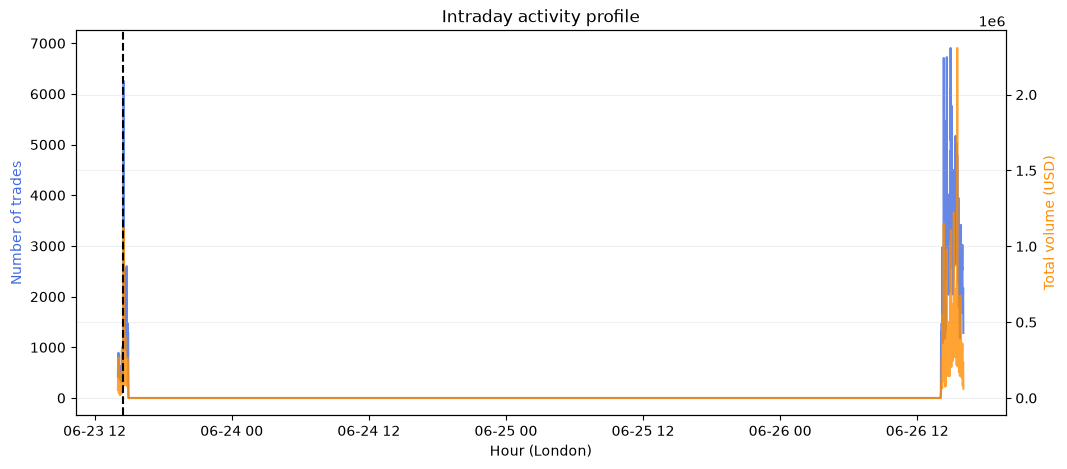

In [5]:
df_activity = df_trades.resample('1Min').agg({
    'trade_id': 'count',    
    'volume_usd': 'sum'     
})

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(df_activity.index, df_activity['trade_id'], color='royalblue', label='Nº de Trades', alpha=0.8)
ax2.plot(df_activity.index, df_activity['volume_usd'], color='darkorange', label='Volumen (USD)', alpha=0.8)

ax1.set_ylabel('Number of trades', color='royalblue')
ax2.set_ylabel('Total volume (USD)', color='darkorange')
ax1.set_xlabel('Hour (London)')

# Línea de la apertura de Nueva York (14:30 en tu gráfico)
plt.axvline(df_activity.index[df_activity.index.time >= pd.Timestamp('14:30:00').time()][0], 
            color='black', linestyle='--', label='Apertura NYSE')

plt.title('Intraday activity profile')
plt.grid(True, alpha=0.2)
plt.show()

Here it is very clear hoy just after the NYSE has opened the volume has spiked, just for it to stabilize hours later, this proves what be deduced after last plot.

Now we will check if the asset is mean-reverting, a basic microstructure theory would argue that this is the case, since everything is just microstructure noise. For checking this, we will see if returns have a negative autocorrelation, if this is the case, the asset is mean-reverting.

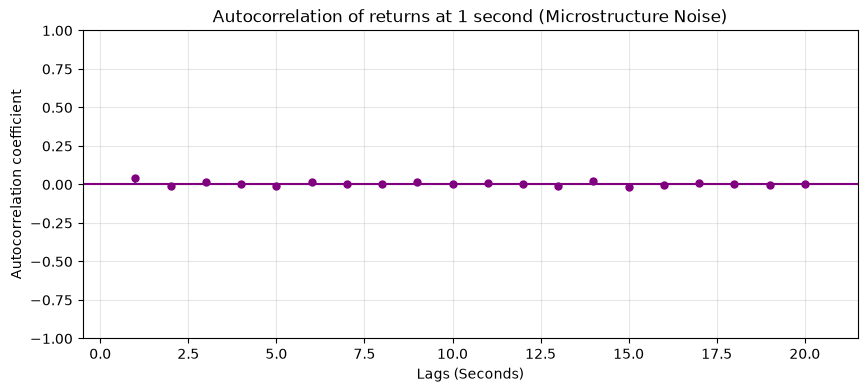

In [6]:
from statsmodels.graphics.tsaplots import plot_acf

mids_1s = df_depth['mid_price'].resample('1s').last().ffill()
returns_1s = mids_1s.pct_change().dropna()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(returns_1s, lags=20, ax=ax, color="purple", alpha=0.05, zero=False)
ax.set_title('Autocorrelation of returns at 1 second (Microstructure Noise)')
ax.set_xlabel('Lags (Seconds)')
ax.set_ylabel('Autocorrelation coefficient')
plt.grid(True, alpha=0.3)
plt.show()

In this plot we observe something interesting: the autocorrelation is almost zero everywhere, this does not necessarily translate to a non-mean-reverting-process since it could be caused because we are samplying events by time. For solving this we will create separate three clocks (time, tick and volume), this can be justified becaused we have just proved that traditional samplying destroys all statistical properties.

=== KURTOSIS OF THE RETURNS ===
Physical clock: 134.12
Event clock: 0.63
Volume clock: 1.08


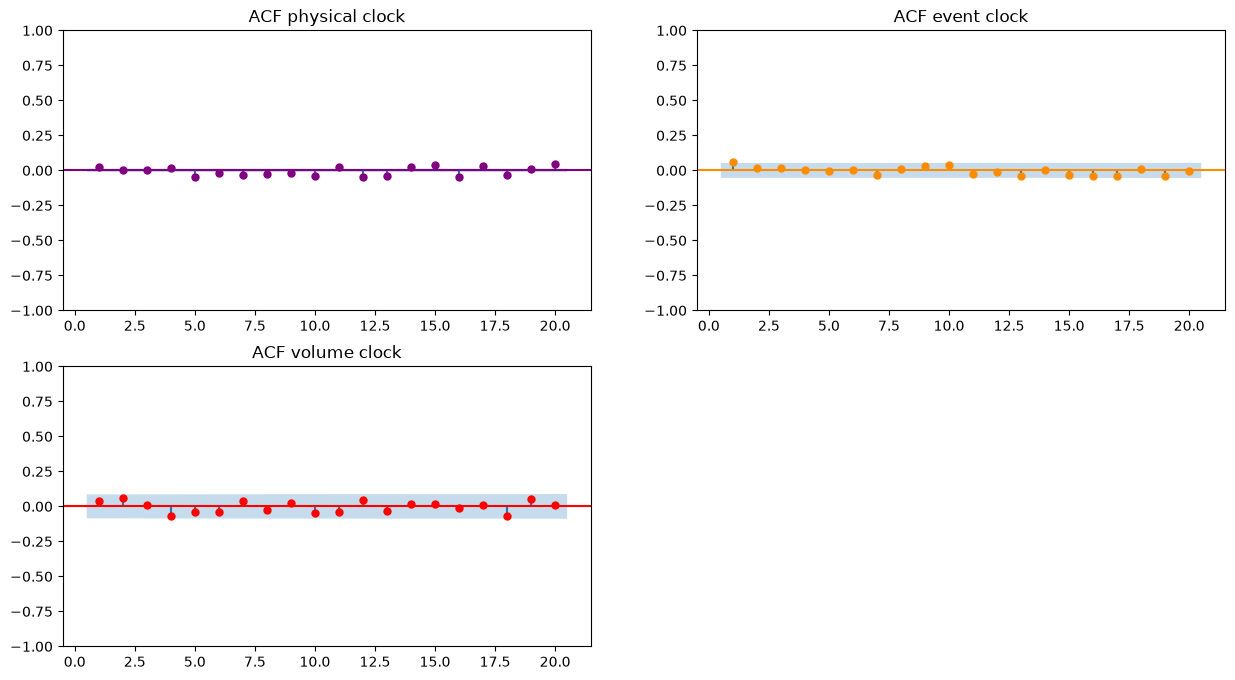

In [25]:
import numpy as np

# Physical clock (10 sec intervals)
time_bars = df_trades['price'].resample('10s').last().ffill()
ret_time = np.log(time_bars / time_bars.shift(1)).dropna()

# Event clock (transactions interval)
df_trades['tick_group'] = np.arange(len(df_trades)) // 300
tick_bars = df_trades.groupby('tick_group')['price'].last()
ret_tick = np.log(tick_bars / tick_bars.shift(1)).dropna()

# Volume clock (operations interval)
df_trades['cum_volume'] = df_trades['quantity'].cumsum()
df_trades['volume_group'] = (df_trades['cum_volume'] // 1500).astype(int)
volume_bars = df_trades.groupby('volume_group')['price'].last()
ret_vol = np.log(volume_bars / volume_bars.shift(1)).dropna()

# Now we can plot the different autocorrelation plots and kurtosis test

import scipy.stats as stats

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 8))

lags = 20

plot_acf(ret_time, lags=lags, ax=ax1, color='purple', alpha=0.05, zero=False)
ax1.set_title('ACF physical clock')

plot_acf(ret_tick, lags=lags, ax=ax2, color='darkorange', alpha=0.05, zero=False)
ax2.set_title('ACF event clock')

plot_acf(ret_vol, lags=lags, ax=ax3, color='red', alpha=0.05, zero=False)
ax3.set_title('ACF volume clock')
ax4.axis('off')

plt.plot()


print("=== KURTOSIS OF THE RETURNS ===")
print(f"Physical clock: {stats.kurtosis(ret_time):.2f}")
print(f"Event clock: {stats.kurtosis(ret_tick):.2f}")
print(f"Volume clock: {stats.kurtosis(ret_vol):.2f}")

Here we get what is going to probably be the most interesting result in all of this analysis, the excess kurtosis of the volume clock returns has dropped to almost zero, indicating that sampling returns in volume-time effectively eliminates fat-tailed bahaviour observed in the physical clock (very high kurtosis), meaning that the returns are almost perfectly normally distributed.

This can be explained by the fact that the vast majority of institutional trading algorithms operate based on volume rather than time.

It is important to note that shifting the volume clock uncovers hidden structural dependencies. While the physical and event clocks resemble just noise (even though a very vague pattern could be extracted from the event clock), the autocorrelation function (ACF) of the volume clock shows a clear cyclical pattern. Even though these autocorrelations do not surpass or vaguely surpass the confidence interval, this mean-reverting sinusoidal structure provides an ideal basis for constructing a signal.

Something extemelly important is that we have not demonstrated that price is mean reverting, we have demostrated that returns are mean reverting, although these are related.

To exploit this microstructure dependencies, we will build our signal around this volume clock, incorporating the formal definition of order flow imbalance (OFI) given by Cont, Kukanov, and Stoikov (2014) in their paper "Price impact of order book events".

In [8]:
import numpy as np
df_depth['prev_bid_p'] = df_depth['bid_p_1'].shift(1)
df_depth['prev_bid_q'] = df_depth['bid_q_1'].shift(1)
df_depth['prev_ask_p'] = df_depth['ask_p_1'].shift(1)
df_depth['prev_ask_q'] = df_depth['ask_q_1'].shift(1)

# Initialize the imbalance variables to zero
df_depth['I_bid'] = 0.0
df_depth['I_ask'] = 0.0

# Buy side logic (bid)
bid_cond_1 = df_depth['bid_p_1'] > df_depth['prev_bid_p']
bid_cond_2 = df_depth['bid_p_1'] == df_depth['prev_bid_p']
bid_cond_3 = df_depth['bid_p_1'] < df_depth['prev_bid_p']

df_depth.loc[bid_cond_1, 'I_bid'] = df_depth['bid_q_1']
df_depth.loc[bid_cond_2, 'I_bid'] = df_depth['bid_q_1'] - df_depth['prev_bid_q']
df_depth.loc[bid_cond_3, 'I_bid'] = 0.0

# Sell side log (ask)
ask_cond_1 = df_depth['ask_p_1'] > df_depth['prev_ask_p']
ask_cond_2 = df_depth['ask_p_1'] == df_depth['prev_ask_p']
ask_cond_3 = df_depth['ask_p_1'] < df_depth['prev_ask_p']

df_depth.loc[ask_cond_1, 'I_ask'] = 0.0
df_depth.loc[ask_cond_2, 'I_ask'] = df_depth['ask_q_1'] - df_depth['prev_ask_q']
df_depth.loc[ask_cond_3, 'I_ask'] = df_depth['ask_q_1']

# Final OFI calculation tick by tick
df_depth['OFI'] = df_depth['I_bid'] - df_depth['I_ask']
df_depth.dropna(inplace=True)

print(f"OFI calculated. Basic statistical values: \n {df_depth['OFI'].describe()}")

OFI calculated. Basic statistical values: 
 count    99841.000000
mean        -2.337615
std        250.905420
min      -5553.711000
25%        -62.364000
50%          0.000000
75%         60.000000
max      13335.356000
Name: OFI, dtype: float64


We observe that the mean is one, which given the price we could interpret almost as zero (we also see the median is 0), this could be interpreted as the OFI being mean reverting.

Now we will continue by building a machine learning model, whose target will not be the price but the direction of the next movement.

In [9]:
# Predictive horizon (eg: the next 10 event from the order book)
horizon = 10

# Calculate future mid-price
df_depth['future_mid'] = df_depth['mid_price'].shift(-horizon)

# Directional target +1 -> increases; -1 -> decreases; 0 -> did not change
df_depth['target_raw'] = np.sign(df_depth['future_mid'] - df_depth['mid_price'])

# For binary classification we remove the 0 case (the price does not change)
df_model_raw = df_depth[df_depth['target_raw'] != 0].copy()

print(f"Distribution of directional target:\n{df_model_raw['target_raw'].value_counts(normalize=True)}")

Distribution of directional target:
target_raw
-1.0    0.504434
 1.0    0.495566
Name: proportion, dtype: float64


Before passing the OFI from the time domain to the event domain, we will analyze if there is any relationship between the OFI and the target.

Pearson correlation (Clean OFI vs Target): 0.1954


/tmp/ipykernel_21625/2328432412.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_raw', y='OFI_clean', data=df_model_raw, palette='coolwarm')


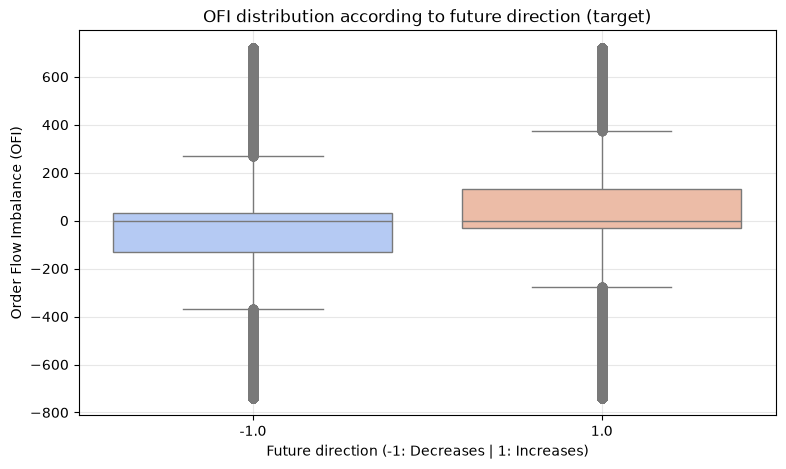

In [10]:
import seaborn as sns

# Remove extreme values since the OFI is too volatile
lower_bound = df_model_raw['OFI'].quantile(0.01)
upper_bound = df_model_raw['OFI'].quantile(0.99)

df_model_raw['OFI_clean'] = df_model_raw['OFI'].clip(lower=lower_bound, upper=upper_bound)

# 2. Pearson correlation
correlation = df_model_raw[['OFI_clean', 'target_raw']].corr().iloc[0, 1]
print(f"Pearson correlation (Clean OFI vs Target): {correlation:.4f}")

# 3. Graph
plt.figure(figsize=(9, 5))
sns.boxplot(x='target_raw', y='OFI_clean', data=df_model_raw, palette='coolwarm')

plt.title('OFI distribution according to future direction (target)')
plt.xlabel('Future direction (-1: Decreases | 1: Increases)')
plt.ylabel('Order Flow Imbalance (OFI)')
plt.grid(True, alpha=0.3)
plt.show()

We can observe that there is almost no correlation, this is caused because we use an OFI based on time events wiouth any synchronization with the volume ticks we showed above were of significant importance.

In [11]:
# Sort them according to time (just in case)
df_depth = df_depth.sort_index()
df_trades = df_trades.sort_index()

# Extract the volume_group we obtained before
df_trades_v_group = df_trades[['volume_group']].reset_index()
df_depth_resetted = df_depth.reset_index()

# We synchronize the data backwards for preventing 'look-ahead bias'
df_sync = pd.merge_asof(
    df_depth_resetted.sort_values('datetime'),
    df_trades_v_group.sort_values('datetime'),
    on='datetime',
    direction='backward'
)

# We group by volume bar for eliminating noise
# Sum all the micro-OFIs in each bar and take the last mid-price
df_volume_clock = df_sync.groupby('volume_group').agg({
    'OFI': 'sum',
    'mid_price': 'last'
}).dropna()

# We create the final target, does the next price increase or decrease
df_volume_clock['next_mid'] = df_volume_clock['mid_price'].shift(-1)
df_volume_clock['target_bar'] = np.sign(df_volume_clock['next_mid'] - df_volume_clock['mid_price'])

# We drop the bars where the price has not change or does not have future data
df_volume_clock_clean = df_volume_clock[df_volume_clock['target_bar'] != 0].dropna().copy()

# Winsorizing for eliminating extreme events
q_low = df_volume_clock_clean['OFI'].quantile(0.01)
q_high = df_volume_clock_clean['OFI'].quantile(0.99)
df_volume_clock_clean['OFI_v_clean'] = df_volume_clock_clean['OFI'].clip(lower=q_low, upper=q_high)

print(f"Synchronization completed. Total useful volume bars: {len(df_volume_clock_clean)}")

Synchronization completed. Total useful volume bars: 1812


Pearson correlation in volume clock: 0.0850


/tmp/ipykernel_21625/4066385117.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_bar', y='OFI_v_clean', data=df_volume_clock_clean, palette='coolwarm')


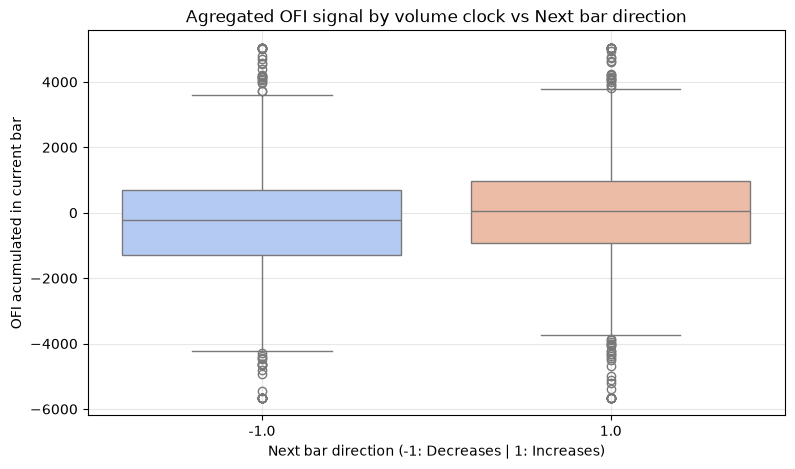

In [12]:
# New structural correlation
new_corr = df_volume_clock_clean[['OFI_v_clean', 'target_bar']].corr().iloc[0, 1]
print(f"Pearson correlation in volume clock: {new_corr:.4f}")

# Graph new distribution
plt.figure(figsize=(9, 5))
sns.boxplot(x='target_bar', y='OFI_v_clean', data=df_volume_clock_clean, palette='coolwarm')

plt.title('Agregated OFI signal by volume clock vs Next bar direction')
plt.xlabel('Next bar direction (-1: Decreases | 1: Increases)')
plt.ylabel('OFI acumulated in current bar')
plt.grid(True, alpha=0.3)
plt.show()

It looks like there is no real edge, since the Pearson correlation (which was already low) has decreased even lower, this could be explained by the fact that we are using a linear model for a non-linear relationship, we will this hipothesis by using a non-linear model (a gradient boosting algorithm). We will use logistic regression for now, a simple linear but widely classic machine learning algorithm.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

X = df_volume_clock_clean[['OFI_v_clean']]
y = df_volume_clock_clean['target_bar']

clf = LogisticRegression(class_weight='balanced')
clf.fit(X, y)

y_pred = clf.predict(X)
y_prob = clf.predict_proba(X)[:, 1] # Probabilidad de que el precio suba (clase 1)

print("=== Predictive power of the OFI (BASELINE ML) ===")
print(classification_report(y, y_pred))

auc = roc_auc_score(y, y_prob)
print(f"AUC-ROC Score: {auc:.4f}")

=== Predictive power of the OFI (BASELINE ML) ===
              precision    recall  f1-score   support

        -1.0       0.53      0.53      0.53       883
         1.0       0.56      0.56      0.56       929

    accuracy                           0.55      1812
   macro avg       0.54      0.54      0.54      1812
weighted avg       0.55      0.55      0.55      1812

AUC-ROC Score: 0.5549


This model is perfect, it looks like we have just beaten the market but it is best if we consider with skepticism this metrics, if we were truly 55-57% of the time correct we would have found a money printing machine, something that is highly improbable. For a more rigorous approach we will use walk-forward validation.

In [14]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# We split the data chronologically into 5 distinct periods
tscv = TimeSeriesSplit(n_splits=5)

acc_scores = []
auc_scores = []

print("=== WALK-FORWARD VALIDATION RESULTS ===")

fold = 1
for train_index, test_index in tscv.split(X):
    # Time strictly flows forward: Train on past, Test on future
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Initialize and train the model
    clf_cv = LogisticRegression(class_weight='balanced')
    clf_cv.fit(X_train, y_train)
    
    # Predict
    y_pred_cv = clf_cv.predict(X_test)
    y_prob_cv = clf_cv.predict_proba(X_test)[:, 1]
    
    # Score
    acc = accuracy_score(y_test, y_pred_cv)
    auc = roc_auc_score(y_test, y_prob_cv)
    
    acc_scores.append(acc)
    auc_scores.append(auc)
    
    print(f"Fold {fold} | Train size: {len(X_train)} | Test size: {len(X_test)} -> Accuracy: {acc:.4f}, AUC: {auc:.4f}")
    fold += 1

print("-" * 40)
print(f"TRUE MEAN ACCURACY: {np.mean(acc_scores):.4f} (Std Dev: {np.std(acc_scores):.4f})")
print(f"TRUE MEAN AUC-ROC:  {np.mean(auc_scores):.4f} (Std Dev: {np.std(auc_scores):.4f})")

=== WALK-FORWARD VALIDATION RESULTS ===
Fold 1 | Train size: 302 | Test size: 302 -> Accuracy: 0.5861, AUC: 0.5825
Fold 2 | Train size: 604 | Test size: 302 -> Accuracy: 0.5629, AUC: 0.5625
Fold 3 | Train size: 906 | Test size: 302 -> Accuracy: 0.5298, AUC: 0.5743
Fold 4 | Train size: 1208 | Test size: 302 -> Accuracy: 0.5497, AUC: 0.5626
Fold 5 | Train size: 1510 | Test size: 302 -> Accuracy: 0.5199, AUC: 0.5132
----------------------------------------
TRUE MEAN ACCURACY: 0.5497 (Std Dev: 0.0236)
TRUE MEAN AUC-ROC:  0.5590 (Std Dev: 0.0241)


Using walk-forward validation we observe that the AUC and the accuracy has decresed dramatically, from an almost money-printing machine to one that is not profitable, this was the actual expected result.

For improving this metric we will two new things:
1. We will use more features: we are currently only using the first level of the order book, we actuallt have 10 levels stored, so we will now use them.
2. We will use a non-linear model, something we suspect is going to capture better the relationship since we already observed a very low Pearson correlation, indicating that the relationship is not linear.

In [15]:
# 1. Milti-level LOB
# Load again the dataset with all the levels
projection = (
    ["event_time", "first_update_id", "final_update_id"] +
    [f"bid_p_{i}" for i in range(1, 11)] +
    [f"bid_q_{i}" for i in range(1, 11)] +
    [f"ask_p_{i}" for i in range(1, 11)] +
    [f"ask_q_{i}" for i in range(1, 11)]
)

df_depth = dataset_depth.to_table(columns=projection).to_pandas()
df_depth['datetime'] = pd.to_datetime(df_depth['event_time'], unit='ms', utc=True).dt.tz_convert('Europe/London')
df_depth.set_index('datetime', inplace=True)

df_depth['mid_price'] = (df_depth['ask_p_1'] + df_depth['bid_p_1']) / 2
df_depth['spread'] = (df_depth['ask_p_1'] - df_depth['bid_p_1']).round(2)

print(f"LOB loaded. Total rows: {len(df_depth)}; Available columns: {len(df_depth.columns)}")
df_depth.head(3)

LOB loaded. Total rows: 99842; Available columns: 45


,event_time,first_update_id,final_update_id,bid_p_1,bid_p_2,bid_p_3,bid_p_4,bid_p_5,bid_p_6,bid_p_7,...,ask_q_3,ask_q_4,ask_q_5,ask_q_6,ask_q_7,ask_q_8,ask_q_9,ask_q_10,mid_price,spread
datetime,,,,,,,,,,,,,,,,,,,,,
2026-06-23 14:02:16.895000+01:00,1782219736895,29359678378,29359678381,68.98,68.97,68.96,68.95,68.94,68.93,68.92,...,575.758,372.120,615.874,647.291,273.325,902.971,493.123,664.44,68.985,0.01
2026-06-23 14:02:16.995000+01:00,1782219736995,29359678382,29359678382,68.98,68.97,68.96,68.95,68.94,68.93,68.92,...,575.758,372.120,615.874,647.291,273.325,902.971,493.123,664.44,68.985,0.01
2026-06-23 14:02:17.195000+01:00,1782219737195,29359678383,29359678431,68.98,68.97,68.96,68.95,68.94,68.93,68.92,...,561.246,386.633,505.207,647.291,273.325,902.971,493.123,664.44,68.985,0.01


In [16]:
# Now we recalculate the OFI
df_depth['prev_bid_p'] = df_depth['bid_p_1'].shift(1)
df_depth['prev_bid_q'] = df_depth['bid_q_1'].shift(1)
df_depth['prev_ask_p'] = df_depth['ask_p_1'].shift(1)
df_depth['prev_ask_q'] = df_depth['ask_q_1'].shift(1)

df_depth['I_bid'] = 0.0
df_depth['I_ask'] = 0.0

bid_cond_1 = df_depth['bid_p_1'] > df_depth['prev_bid_p']
bid_cond_2 = df_depth['bid_p_1'] == df_depth['prev_bid_p']
bid_cond_3 = df_depth['bid_p_1'] < df_depth['prev_bid_p']

df_depth.loc[bid_cond_1, 'I_bid'] = df_depth['bid_q_1']
df_depth.loc[bid_cond_2, 'I_bid'] = df_depth['bid_q_1'] - df_depth['prev_bid_q']
df_depth.loc[bid_cond_3, 'I_bid'] = 0.0

ask_cond_1 = df_depth['ask_p_1'] > df_depth['prev_ask_p']
ask_cond_2 = df_depth['ask_p_1'] == df_depth['prev_ask_p']
ask_cond_3 = df_depth['ask_p_1'] < df_depth['prev_ask_p']

df_depth.loc[ask_cond_1, 'I_ask'] = 0.0
df_depth.loc[ask_cond_2, 'I_ask'] = df_depth['ask_q_1'] - df_depth['prev_ask_q']
df_depth.loc[ask_cond_3, 'I_ask'] = df_depth['ask_q_1']

df_depth['OFI'] = df_depth['I_bid'] - df_depth['I_ask']
df_depth.dropna(inplace=True)

print(f"OFI recalculated. Rows: {len(df_depth)}")
print(df_depth['OFI'].describe())

OFI recalculated. Rows: 99841
count    99841.000000
mean        -2.337615
std        250.905420
min      -5553.711000
25%        -62.364000
50%          0.000000
75%         60.000000
max      13335.356000
Name: OFI, dtype: float64


In [17]:
# Separate buy and sell
df_trades['buy_volume'] = df_trades['quantity'].where(~df_trades['is_buyer_maker'], 0)
df_trades['sell_volume'] = df_trades['quantity'].where(df_trades['is_buyer_maker'], 0)

# Aggreagate per volume bar
trade_agg = df_trades.groupby('volume_group').apply(
    lambda g: pd.Series({
        'buy_vol': g['buy_volume'].sum(),
        'sell_vol': g['sell_volume'].sum(),
        'n_trades': g['trade_id'].count(),
        'vwap': np.average(g['price'], weights=g['quantity']) if g['quantity'].sum() > 0 else np.nan
    })
).reset_index()

# Trade imbalance
trade_agg['trade_imbalance'] = (trade_agg['buy_vol'] - trade_agg['sell_vol']) / \
                                (trade_agg['buy_vol'] + trade_agg['sell_vol'] + 1e-9)

print(f"Trade aggregation completed. Bars: {len(trade_agg)}")
print(trade_agg[['trade_imbalance', 'n_trades', 'vwap']].describe())

Trade aggregation completed. Bars: 2572
       trade_imbalance     n_trades         vwap
count      2572.000000  2572.000000  2572.000000
mean          0.001143   157.714619    70.160041
std           0.717121   135.019385     1.052533
min          -1.000000     1.000000    68.202850
25%          -0.704188    47.000000    69.081283
50%           0.007437   127.000000    70.511127
75%           0.694679   237.000000    71.000000
max           1.000000   864.000000    71.966130


In [18]:
# Queue imbalance for the first 5 levels (most relevant)
for i in range(1, 6):
    df_depth[f'qi_{i}'] = (
        (df_depth[f'bid_q_{i}'] - df_depth[f'ask_q_{i}']) /
        (df_depth[f'bid_q_{i}'] + df_depth[f'ask_q_{i}'] + 1e-9)
    )

# Acumulated depth (5 levels)
df_depth['total_bid_depth'] = sum(df_depth[f'bid_q_{i}'] for i in range(1, 6))
df_depth['total_ask_depth'] = sum(df_depth[f'ask_q_{i}'] for i in range(1, 6))
df_depth['depth_imbalance'] = (
    (df_depth['total_bid_depth'] - df_depth['total_ask_depth']) /
    (df_depth['total_bid_depth'] + df_depth['total_ask_depth'] + 1e-9)
)

# Synchrinize with the volume clock (again)
df_depth_r = df_depth.sort_index().reset_index()
df_trades_v = df_trades[['volume_group']].reset_index()

df_sync = pd.merge_asof(
    df_depth_r.sort_values('datetime'),
    df_trades_v.sort_values('datetime'),
    on='datetime',
    direction='backward'
)

# Aggregate per volume bar: summed OFI, average features, final mid_price
agg_dict = {
    'OFI': 'sum',
    'mid_price': 'last',
    'depth_imbalance': 'mean',
}
for i in range(1, 6):
    agg_dict[f'qi_{i}'] = 'mean'

df_vc = df_sync.groupby('volume_group').agg(agg_dict).dropna()

# Merge with trade_agg
df_vc = df_vc.merge(
    trade_agg[['volume_group', 'trade_imbalance', 'n_trades']].set_index('volume_group'),
    left_index=True, right_index=True, how='left'
)

print(f"Feature set build. Bars: {len(df_vc)}")
print(f"Columns: {list(df_vc.columns)}")
df_vc.head(3)

Feature set build. Bars: 2070
Columns: ['OFI', 'mid_price', 'depth_imbalance', 'qi_1', 'qi_2', 'qi_3', 'qi_4', 'qi_5', 'trade_imbalance', 'n_trades']


,OFI,mid_price,depth_imbalance,qi_1,qi_2,qi_3,qi_4,qi_5,trade_imbalance,n_trades
volume_group,,,,,,,,,,
0.0,179.249,68.985,0.302054,0.043152,0.122959,0.237477,0.287427,0.553922,0.935911,119.0
1.0,-224.669,68.985,0.275580,-0.077260,0.135605,0.086316,0.331301,0.577258,-1.000000,35.0
2.0,-472.640,68.955,0.175685,0.100541,0.059306,0.084854,0.159131,0.349625,-0.141824,394.0


In [19]:
# Bar returns
df_vc['ret'] = df_vc['mid_price'].pct_change()

# Momentum: returns of last two bars (continuation vs reversion signal)
df_vc['ret_lag1'] = df_vc['ret'].shift(1)
df_vc['ret_lag2'] = df_vc['ret'].shift(2)

# Target, but only predicting when the movement is significative (with threshold)
vol = df_vc['ret'].std()
threshold = 0.3 * vol

df_vc['target'] = 0
df_vc.loc[df_vc['ret'].shift(-1) > threshold, 'target'] = 1
df_vc.loc[df_vc['ret'].shift(-1) < -threshold, 'target'] = -1

df_model = df_vc[df_vc['target'] != 0].dropna().copy()

print(f"Bars with significant movement: {len(df_model)} out of {len(df_vc)}")
print(f"Target distribucion:\n{df_model['target'].value_counts()}")
print(f"Threshold usado: {threshold:.6f} ({threshold*100:.4f}%)")

Bars with significant movement: 1374 out of 2070
Target distribucion:
target
 1    708
-1    666
Name: count, dtype: int64
Threshold usado: 0.000169 (0.0169%)


In [20]:
feature_cols = ['OFI', 'depth_imbalance', 'qi_1', 'qi_2', 'qi_3', 'qi_4', 'qi_5',
                'trade_imbalance', 'ret_lag1', 'ret_lag2']

# Winsorizing
for col in feature_cols:
    q_low = df_model[col].quantile(0.01)
    q_high = df_model[col].quantile(0.99)
    df_model[col] = df_model[col].clip(lower=q_low, upper=q_high)

X = df_model[feature_cols]
y = df_model['target']

print(f"Shape of X: {X.shape}")
print(f"Features:\n{X.describe().round(4)}")

Shape of X: (1374, 10)
Features:
             OFI  depth_imbalance       qi_1       qi_2       qi_3       qi_4  \
count  1374.0000        1374.0000  1374.0000  1374.0000  1374.0000  1374.0000   
mean   -118.9364           0.0082    -0.0092     0.0232     0.0286     0.0215   
std    1903.3055           0.2486     0.3185     0.2789     0.2886     0.3109   
min   -5668.5039          -0.5262    -0.8295    -0.6078    -0.6116    -0.7193   
25%   -1165.8875          -0.1833    -0.1959    -0.1512    -0.1679    -0.2011   
50%     -53.2530           0.0169    -0.0248     0.0122     0.0287     0.0299   
75%     857.5975           0.1894     0.1667     0.1943     0.2224     0.2400   
max    5104.6089           0.5818     0.9042     0.7415     0.7647     0.7105   

            qi_5  trade_imbalance   ret_lag1   ret_lag2  
count  1374.0000        1374.0000  1374.0000  1374.0000  
mean     -0.0061          -0.0124     0.0000     0.0000  
std       0.2964           0.6448     0.0006     0.0005  
min  

Now that we have implemented the first change, we will use LightGBM, a gradient boosting algorithm, for testing, using walk-forward validation and we will see if the AUC score and accuracy have increased.

In [21]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

# LightGBM needs y to be 0/1, not -1/1
le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(y), index=y.index)
# Class 0 = decreases, Class 1 = increases (can be verified with le.classes_)
print(f"Codified classes: {le.classes_} -> [0, 1]")

tscv = TimeSeriesSplit(n_splits=5)
acc_scores = []
auc_scores = []

print("\n=== WALK-FORWARD VALIDATION (LightGBM, 10 features) ===")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded.iloc[train_idx], y_encoded.iloc[test_idx]

    clf = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=15,        # Low for preventing overfitting for few samples.
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    acc_scores.append(acc)
    auc_scores.append(auc)
    print(f"Fold {fold} | Train: {len(X_train)} | Test: {len(X_test)} -> Accuracy: {acc:.4f}, AUC: {auc:.4f}")

print("-" * 50)
print(f"MEAN ACCURACY: {np.mean(acc_scores):.4f}  (std: {np.std(acc_scores):.4f})")
print(f"MEAM AUC-ROC:  {np.mean(auc_scores):.4f}  (std: {np.std(auc_scores):.4f})")

Codified classes: [-1  1] -> [0, 1]

=== WALK-FORWARD VALIDATION (LightGBM, 10 features) ===
Fold 1 | Train: 229 | Test: 229 -> Accuracy: 0.5459, AUC: 0.5503
Fold 2 | Train: 458 | Test: 229 -> Accuracy: 0.5066, AUC: 0.5026
Fold 3 | Train: 687 | Test: 229 -> Accuracy: 0.5677, AUC: 0.5774
Fold 4 | Train: 916 | Test: 229 -> Accuracy: 0.5240, AUC: 0.5096
Fold 5 | Train: 1145 | Test: 229 -> Accuracy: 0.5240, AUC: 0.5388
--------------------------------------------------
MEAN ACCURACY: 0.5336  (std: 0.0211)
MEAM AUC-ROC:  0.5358  (std: 0.0274)
